# Step 1: Google Drive Mount and Environment Setup

In [ ]:
from google.colab import drive
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Mount Google Drive to access the dataset
drive.mount('/content/drive')

# The path to the dataset folder
base_path = "./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master"
train_dir = os.path.join(base_path, 'Training')
val_dir = os.path.join(base_path, 'Testing')

print("Drive mounted successfully. Checking paths...")
print("Train directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(val_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully. Checking paths...
Train directory exists: True
Validation directory exists: True


# Step 2: Imports and Data Augmentation (Transforms)



In [ ]:
# Mild augmentations to preserve brain anatomy and structure
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      # Natural left-right symmetry
    transforms.RandomRotation(degrees=10),       # Very mild rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Controlled intensity variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms without any augmentations
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets directly from your specific Google Drive paths
train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = ImageFolder(root=val_dir, transform=val_transforms)

# Define data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset Loaded. Classes found: {train_dataset.classes}")

Dataset Loaded. Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


# Step 3: Pretrained Model Loading and Strict Freezing

In [ ]:
import torch.nn as nn
import torchvision.models as models

# Load pretrained ResNet18 backbone
model = models.resnet18(pretrained=True)

# Freeze all feature extraction layers to prevent shortcut learning
for param in model.parameters():
    param.requires_grad = False

# Replace the final classifier head for our 4 specific classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Step 4: Loss Function and Optimizer Setup



In [ ]:
# Use standard CrossEntropyLoss without manual class weights for baseline evaluation
criterion = nn.CrossEntropyLoss()

# Optimize ONLY the parameters of the final fc layer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Step 5 :Training Loop with Auto-Saving Checkpoint

In [ ]:
epochs = 4 # Short training phase to evaluate baseline feature behavior

best_acc = 0.0

# Define checkpoint file path in Drive
checkpoint_path = os.path.join(base_path, 'best_brain_tumor_model.pth')

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass and optimization
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}%")

    # Save the best model checkpoint based on accuracy
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss,
            'accuracy': epoch_acc
        }, checkpoint_path)
        print(f"--> Saved best checkpoint to: {checkpoint_path}")

Epoch [1/4] - Loss: 0.9551 - Acc: 61.99%
--> Saved best checkpoint to: ./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master/best_brain_tumor_model.pth
Epoch [2/4] - Loss: 0.6136 - Acc: 78.36%
--> Saved best checkpoint to: ./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master/best_brain_tumor_model.pth
Epoch [3/4] - Loss: 0.5538 - Acc: 79.72%
--> Saved best checkpoint to: ./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master/best_brain_tumor_model.pth
Epoch [4/4] - Loss: 0.5240 - Acc: 79.41%


# Step 6 : Confusion Matrix and Clean Prediction Evaluation

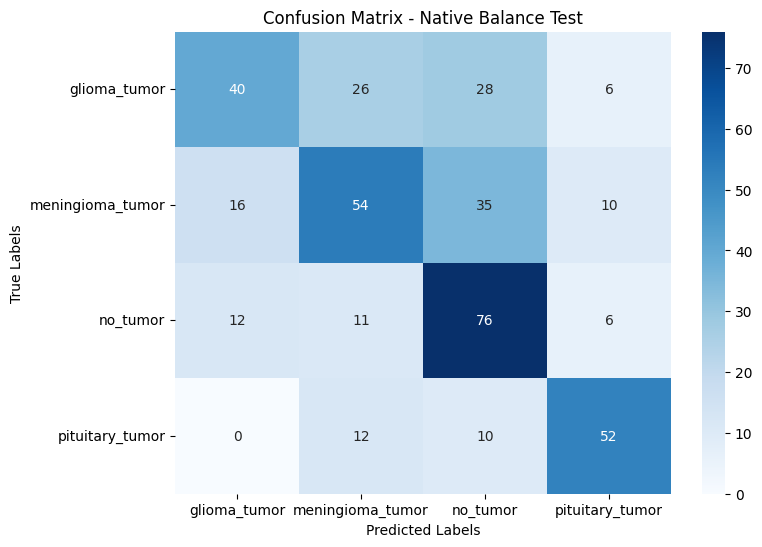

                  precision    recall  f1-score   support

    glioma_tumor       0.59      0.40      0.48       100
meningioma_tumor       0.52      0.47      0.50       115
        no_tumor       0.51      0.72      0.60       105
 pituitary_tumor       0.70      0.70      0.70        74

        accuracy                           0.56       394
       macro avg       0.58      0.57      0.57       394
    weighted avg       0.57      0.56      0.56       394



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

# Gather all predictions from the validation set
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Native Balance Test')
plt.show()

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))